# All Analysis

This notebooks aims at making All-encompasing Data Frame and Structures as well as Explore data on a more Inter-Subject Level


## Preprocessing 

#### Parameters and env creations:

Get our parameters. Create all necessery Directories and Name our analyses

In [31]:
#### ---- Options File ---- ####

import os 
import pandas as pd
import numpy as np

import pickle#### ---- Options File ---- ####

import os 
import pandas as pd
import numpy as np

import pickle

ExpName = 'SecondExp'  # 'FirstExperiment' or 'SecondExp'

### Options
mm = True;                 # Whethert to gather MM 
est            = 'zscore'  # Whether to Zscore the data: # 'Zscore' or ''  
partial        = ''        # Whetheer to test Part of Experiment (first or second half): # 'first' or 'second' or ''
excludeDs      =[]; #["DS03", "DS08","DS14","DS23"] #["DS03", "DS08","DS14","DS23"]#["DS03", "DS08","DS14","DS23"]  # DS04 or DS25  # Excludsion of given subjects (List)  ['DS04','DS25'];
excludeDSTrial = []        # Exclusion of specific trials in a given DS: # construct our tuple out of values from both olumn thus making it easier to compare via isin() 
if len(excludeDs) >0:
    exclusionName= '_'.join(excludeDs)
else:
    exclusionName= ''

### Analysis Name 
# First Experiment: NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean
# Second Experiment: TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trO10000_trB5000mean
currentANalysisName = "NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean"
workingDir = os.getcwd();

### Create a Directory for Summary Statistics: W
statPath = (os.path.join(workingDir,ExpName,currentANalysisName,'summary',f"mode_{est}_{partial}_{exclusionName}_mm{mm}"))
os.makedirs(statPath, exist_ok=True)

### Path for Remembering Data if Applicable
if ExpName == 'SecondExp':
    VIZFOLDER = f"alt_extrF_{4}_{True}_all"
    loadPathFeatures = os.path.join(workingDir,ExpName,'RecallAnalysis',VIZFOLDER)



### Create a .gitignore file in the summary directory
gi_path = os.path.join(workingDir,ExpName,currentANalysisName, ".gitignore")
gitignore_text = """\
# Ignore everything in this folder
*

# …but keep this file
!.gitignore
"""
# Only create it if it’s not already there
if not os.path.isfile(gi_path):
    with open(gi_path, "w", encoding="utf-8") as fh:
        fh.write(gitignore_text)

### Open Final stat Log: 
log_file = open(os.path.join(statPath,f"finalStatLog_{est}_{exclusionName}_Behav.txt"),'w+')


### Create Empty Result Data Structures:
# For Testing Main Effects 
coefs = []
zvals = []
pvals = []
conf1 = []
conf2 = []

# For Testing Trial Effect
coefsT = []
zvalsT = []
pvalsT = []
conf1T = []
conf2T = []

indx     = []
eye      = []
analysis = []


In [32]:
### Load Data By Subjects --> Greater Validity

subjects = [f for f in os.listdir(os.path.join(workingDir,ExpName,currentANalysisName,'individuals')) if  not os.path.isfile(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'individuals'), f))] # get all the filenames
subjects
allData = []
subjDict = {}
for i,subj in enumerate(subjects):
    print(f"DS{int(i+1):02d}: Processing subject {subj}")
    subjDict[f"DS{int(i+1):02d}"] = subj
    with open(os.path.join(workingDir,ExpName,currentANalysisName,'individuals',subj,f"{subj}_preprocessed.pickle"), 'rb') as file:
        currData = pickle.load(file)  # Call load method to deserialze
        #shutil.copyfile(os.path.join(workingDir,ExpName,currentANalysisName,'individuals',subj,f"{subj}_preprocessed.pickle"), os.path.join(os.path.split(workingDir)[0],'DataPack',ExpName,f"{subj}_preprocessed.pickle"))
        allData.append(currData)


DS01: Processing subject ADNA2507
DS02: Processing subject AGBA0708
DS03: Processing subject ANBA2308
DS04: Processing subject ANGU1309
DS05: Processing subject ANLU2607
DS06: Processing subject ANSW1409
DS07: Processing subject BAZA2108
DS08: Processing subject BEWA2308
DS09: Processing subject EDJA1309
DS10: Processing subject ELMA2108
DS11: Processing subject EWSI2308
DS12: Processing subject IGWI1409
DS13: Processing subject IZPR2608
DS14: Processing subject JAJA2108
DS15: Processing subject JUBE2907
DS16: Processing subject JUWO0708
DS17: Processing subject KABE2308
DS18: Processing subject KAFI2108
DS19: Processing subject KLKR2608
DS20: Processing subject MAMA2608
DS21: Processing subject MANI2607
DS22: Processing subject MIGO2607
DS23: Processing subject MOWA1009
DS24: Processing subject NIZA2907
DS25: Processing subject OSJA1309
DS26: Processing subject PASZ2608
DS27: Processing subject PIKR2907
DS28: Processing subject SAMA1409
DS29: Processing subject TYTO1309
DS30: Processi

### Preprocess Behav Data:

Preprocessing Aimed at getting True data and making one big structure:

-- grand_df - containing all Behavioral Data and Data Quality Checks


In [33]:
log_file = open(os.path.join(statPath,f"finalStatLog_{est}_{exclusionName}.txt"),'w+')

from analysisFunctions import getPupilDiamLast
def pad_columns(df: pd.DataFrame, depth: int, fill='') -> pd.DataFrame:
    """
    Ensure df.columns is a MultiIndex with exactly `depth` levels.
    Missing levels are right-padded with `fill`.
    """
    if not isinstance(df.columns, pd.MultiIndex):
        # single-level → promote to MultiIndex
        df.columns = pd.MultiIndex.from_tuples([(c,) + (fill,) * (depth - 1) for c in df.columns])
    elif df.columns.nlevels < depth:
        df.columns = pd.MultiIndex.from_tuples(
            [tuple(col) + (fill,) * (depth - len(col)) for col in df.columns]
        )
    return df


dfs = []
target_depth = 3  # we want every DataFrame to have 3 column levels
last10sDF = []


for i, ds in enumerate(allData):

    # --- Pupil Last 10s! ---- ---------------------------------------
    karolinaLast10s,janekLast10s,last10sDF = getPupilDiamLast(ds,last10sDF,beg=5000,mode="all" ) #Cut first 5000 trials

    # --- pupilMW ----------------------------------------------------
    pupil = ds['pupilMW'].copy()
    pupil = pad_columns(pupil, target_depth)

    # Add ID columns **with the same depth**
    pupil[('DS', '', '')] = f'DS{i + 1}'
    pupil[('trialNum', '', '')] = np.arange(1, len(pupil) + 1)

    # --- storyIndCheck ---------------------------------------------
    story = allData[i]['checkInfo']['storyIndCheck'].copy()

    # Ensure the second level retains original column names
    story.columns = pd.MultiIndex.from_tuples(
        [('Checks', '' ,col) for col in story.columns]
    )
    story = pad_columns(story, target_depth)  # Promote to 3 levels

    pupil['MW_Estimate'] = pupil['MW Estimate']
    pupil = pupil[['MW_Estimate','Tracking','DS','trialNum']]
    pupil.columns = pupil.columns.get_level_values(0)

    # --- join for this participant ---------------------------------
    dfs.append(pd.concat([pupil, story['Checks'][''][['goodRatioLeft', 'goodPupRatioLeft','saccadeRate','blinkRate','gazeRate']]], axis=1))

# Combine all participants into one big DataFrame
grand_df = pd.concat(dfs, axis=0, ignore_index=True)

# Remove spaces from all levels of MultiIndex column names
grand_df.columns = grand_df.columns.map(
    lambda col: tuple(c.replace(' ', '_') for c in col) if isinstance(col, tuple) else col
)

### Removing Occular Features 

### Logging
log_file.write(" "*15+"="*58 + "\n")
log_file.write(" "*15+"="*5+ " "*15+" FINAL STATISTICS LOG:"+ " "*15+"="*5+ " \n")
log_file.write(" "*15+"="*58 + "\n\n")
log_file.write("\n===# Descriptives #=== \n\n")
log_file.write(f"      N.Subjects                   {len(allData)}\n")
log_file.write(f"      N. Trials                    {len(np.unique(grand_df['trialNum']))}\n")
log_file.write(f"      Mean Good Data across Subj:  {grand_df['goodRatioLeft'].mean():3.3f}\n")
log_file.write(f"      Tracked MW across Subj:      {grand_df[grand_df['Tracking']=='TRACKED']['MW_Estimate'].mean():3.3f} ({grand_df[grand_df['Tracking']=='TRACKED']['MW_Estimate'].std():3.3f})\n")
log_file.write(f"      Untracked MW across Subj:    {grand_df[grand_df['Tracking']=='UNTRACKED']['MW_Estimate'].mean():3.3f} ({grand_df[grand_df['Tracking']=='UNTRACKED']['MW_Estimate'].std():3.3f})\n")


### Change the name of a column for better readability
import re
grand_df['DS'] = grand_df['DS'].str.replace(
    r'DS(\d+)',                       # grab the digits after “DS”
    lambda m: f'DS{int(m.group(1)):02d}',  # re-emit them with 2-digit zero-padding
    regex=True
)


from analysisFunctions import add_ds_trial_tracking
df_last10s_all = add_ds_trial_tracking(last10sDF, grand_df)


grand_df

,MW_Estimate,Tracking,DS,trialNum,goodRatioLeft,goodPupRatioLeft,saccadeRate,blinkRate,gazeRate
0,37.0,UNTRACKED,DS01,1,0.985204,0.999734,2.302091,1.174536,0.082989
1,1.0,TRACKED,DS01,2,0.984472,1.000000,2.257196,1.076828,0.071473
2,2.0,UNTRACKED,DS01,3,0.984744,1.000000,2.461236,1.329067,0.095719
3,0.0,TRACKED,DS01,4,0.969668,1.000000,2.187206,1.222954,0.084509
4,27.0,UNTRACKED,DS01,5,0.978186,1.000000,2.847956,1.607717,0.116102
...,...,...,...,...,...,...,...,...,...
1195,7.0,UNTRACKED,DS30,36,0.959306,0.978412,5.591260,2.870608,0.192118
1196,12.0,TRACKED,DS30,37,0.953891,0.966102,4.880429,2.879453,0.208264
1197,8.0,UNTRACKED,DS30,38,0.977396,1.000000,4.928781,2.713091,0.189195
1198,9.0,TRACKED,DS30,39,0.969072,0.984604,4.774714,2.600314,0.176863


#### Add Attentiveness Info if the second experiment is being processed

In [34]:


if ExpName =='SecondExp':
    savePathRecall = os.path.join(workingDir,ExpName,'Recalls')       # Save Path for Recall results

    subjPaths = [ f.name for f in os.scandir(savePathRecall) if f.is_dir() ]

    dfAnalysis = pd.read_excel(os.path.join(loadPathFeatures,"features.xlsx"), index_col=0)
    dfAnalysis = dfAnalysis[[	'Subject',	'Fragment',	'Attention','lemmaN','utt_leng','FragmentSentCosSim']]

    dfAnalysis.reset_index(drop=True,inplace=True) # Reset Index to avoid issues with merging
    grand_df.reset_index(drop=True,inplace=True)

    dfAnalysis['DS'] = dfAnalysis['Subject']
    # Create a mapping from subject IDs to DS codes
    fragmentEquivalenceDF = pd.read_excel( os.path.join(workingDir,ExpName,'RecallAnalysis',VIZFOLDER,"fragEquiv.xlsx"), index_col=0)
    dfAnalysis = dfAnalysis.merge(fragmentEquivalenceDF,on="Fragment")


    for i,name in enumerate(dfAnalysis['Subject'].unique()):
        dfAnalysis['DS'][dfAnalysis['Subject'] ==name] =  f'DS{int(i+1):02d}'   


    dfAnalysis['Attention2'] =  dfAnalysis["Attention"].apply(lambda x: 1 if x in [1,2] else 3)

    dfAnalysis['trialNum'] +=1

    # Sort Values not to feel lost
    dfAnalysis.sort_values(by=['DS','trialNum'],inplace=True)
    
    grand_df = pd.merge(grand_df,dfAnalysis,on=['DS','trialNum'],how='left')


### Save the data: 
#grand_df.to_excel(os.path.join(os.path.join(workingDir,ExpName,currentANalysisName,'summary'),"all_data_behav_only.xlsx"))



C:\Users\barak\AppData\Local\Temp\ipykernel_55212\1818419678.py:19: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dfAnalysis['DS'][dfAnalysis['Subject'] ==name] =  f'DS{int(i+1):02d}'
C:\Users\barak\AppData\Local\Temp\ipykernel_55212\1818419

In [35]:
grand_df

,MW_Estimate,Tracking,DS,trialNum,goodRatioLeft,goodPupRatioLeft,saccadeRate,blinkRate,gazeRate,Subject,Fragment,Attention,lemmaN,utt_leng,FragmentSentCosSim,Attention2
0,37.0,UNTRACKED,DS01,1,0.985204,0.999734,2.302091,1.174536,0.082989,ADNA2507,recall_KAROLINA_1,3.0,10.0,118.0,0.271289,3.0
1,1.0,TRACKED,DS01,2,0.984472,1.000000,2.257196,1.076828,0.071473,ADNA2507,recall_JANEK_1,1.0,12.0,121.0,0.323691,1.0
2,2.0,UNTRACKED,DS01,3,0.984744,1.000000,2.461236,1.329067,0.095719,ADNA2507,recall_KAROLINA_2,1.0,16.0,216.0,0.185791,1.0
3,0.0,TRACKED,DS01,4,0.969668,1.000000,2.187206,1.222954,0.084509,ADNA2507,recall_JANEK_2,1.0,10.0,116.0,0.375014,1.0
4,27.0,UNTRACKED,DS01,5,0.978186,1.000000,2.847956,1.607717,0.116102,ADNA2507,recall_KAROLINA_3,2.0,15.0,154.0,0.376438,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,7.0,UNTRACKED,DS30,36,0.959306,0.978412,5.591260,2.870608,0.192118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1196,12.0,TRACKED,DS30,37,0.953891,0.966102,4.880429,2.879453,0.208264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1197,8.0,UNTRACKED,DS30,38,0.977396,1.000000,4.928781,2.713091,0.189195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1198,9.0,TRACKED,DS30,39,0.969072,0.984604,4.774714,2.600314,0.176863,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Exclusion and Modifier appication

Here We make a possibe Data Exclusion based on DS number and previous Occular Assessment: 
As well as apply any data transformation and modifiers such as removing NaN, Zscores



In [36]:
## -- Joice of DS -- ##
grand_df = grand_df[~grand_df['DS'].isin(excludeDs)]

## -- Joice of DS AND Trials --##
filtered_df = grand_df[~grand_df[['DS', 'trialNum']].apply(tuple, axis=1).isin(excludeDSTrial)]

## -- Z score of MW Estimate -- 
if est == 'zscore': 
    grand_df['MW_Estimate'] = grand_df.groupby('DS')['MW_Estimate'].transform(
        lambda x: (x - x.mean()) / x.std() ) # Transforms a DataFrame BY GROUP but returns the original Data Frame! 

## --- Only Part of Trials -- ##
if partial == 'second':
    grand_df  = grand_df[(grand_df[('trialNum', '', '')] > 20) & (grand_df[('trialNum', '', '')] <= 40)]
elif partial =='first':
    grand_df  = grand_df[(grand_df[('trialNum', '', '')] <= 20)]

#### Remove NaN values from grand_df + BUT ONLZ FROM oUR MAIN ANALysis coLUMNS
if ExpName =='SecondExp':

    grand_df= grand_df[grand_df[['MW_Estimate','Attention2']].isna().sum(axis=1)==0]
else:
    grand_df= grand_df[grand_df[['MW_Estimate']].isna().sum(axis=1)==0]

In [37]:
grand_df[grand_df['MW_Estimate'] >=  np.mean(grand_df['MW_Estimate'])].groupby('Tracking')['MW_Estimate'].count()

Tracking
TRACKED      184
UNTRACKED    259
Name: MW_Estimate, dtype: int64

## (1) GENERAL: Test Is Tracked Entity Different from Untracked Entity?

### (1.1) Test Whether Pupil Diameter Differs between Tracked and Untracked Entity: 

We controll immediatley for SUBJECTS

so Making Basic Models:

        MW_estimate ~ Tracking +trialNum + (1|Subjects)


Additionally we plot the Envelope of STD from subjects as well as provide the Mean differs across subjects of MW Both in TIme as in Absolute:

Important here to check:
+ Whether there is a difference between Tracked and Untracked Entity
+ Whether there is an Effect of Trial Number (As MW Rate should increase in time)

In [38]:

def plotTrialTrack(m,name,grand_df,ax,titl,paramNum=[0,1,2],anlysisName = 'Tracking',firstContrast='TRACKED',lastContrast = 'UNTRACKED'):
    ### QUick Linear Model 
    quick_untracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[1]]]+m.params[m.params.keys()[paramNum[2]]]*x 
    quick_tracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[2]]]*x

    trialN = np.linspace(0,len(np.unique(grand_df['trialNum'])),len(np.unique(grand_df['trialNum']))+1);
    mw_est_utr = pd.Series(trialN).apply(quick_untracked_lm)
    mw_est_tr = pd.Series(trialN).apply(quick_tracked_lm)

    ax.set_title(titl)
    ax.plot(trialN,mw_est_tr,label="Tracked model slope",color="blue",linewidth=4,linestyle='--')
    ax.plot(trialN,mw_est_utr,label="Tracked model slope",color="orange",linewidth=4)
    grTr = grand_df[[name,'trialNum',anlysisName]].groupby([anlysisName,'trialNum'])
    from scipy.stats import t

    # --- pieces from the fitted model ---
    Vbeta  = m.cov_params().loc[m.params.index, m.params.index]  # Cov(beta)
    tval   = t.ppf(0.975, df=m.df_resid)                         # 95% PI; change if needed

    # --- build X matrices consistent with your lambdas: [1, Tracking, trialNum] ---
    pnames = list(m.params.index)                # keeps exact column order used by model
    col = {name:i for i, name in enumerate(pnames)}

    def build_X(tracking): # Build simple model matrix (for tracked and untracked separately)
        X = np.zeros((len(trialN), len(pnames)))
        # these names match the terms in your formula
        X[:, col.get('Intercept', 0)] = 1.0
        if anlysisName == "Tracking":
            ttr =  'Tracking[T.UNTRACKED]'
        else:
            ttr =  'C(Attention)[T.3]'

        if ttr in col: X[:, col[ttr]] = tracking
        if 'trialNum' in col: X[:, col['trialNum']] = trialN
        return X

    X_tr  = build_X(1.0)   # tracked
    X_un  = build_X(0.0)   # untracked
    # --- se of mean and se of prediction at each trial ---
    se_mean_tr = np.sqrt(np.einsum('ij,jk,ik->i', X_tr, Vbeta.values, X_tr))
    se_mean_un = np.sqrt(np.einsum('ij,jk,ik->i', X_un, Vbeta.values, X_un))


    # --- add ribbons using your lambdas' fitted lines ---
    ax.fill_between(trialN, mw_est_tr  - tval*se_mean_tr, mw_est_tr  + tval*se_mean_tr,
                    color='mediumslateblue', alpha=0.25, label='TRACKED 95% PI')
    ax.fill_between(trialN, mw_est_utr - tval*se_mean_un, mw_est_utr + tval*se_mean_un,
                color='moccasin', alpha=0.25, label='UNTRACKED 95% PI')


    ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue',linewidth=5)
    ax.scatter(grTr.mean().loc[lastContrast].index,grTr.mean().loc[lastContrast],label="Subj Mean Untracked",color = 'orange',linewidth=5)
    ax.set_xlabel="Trial Number"
    ax.legend()

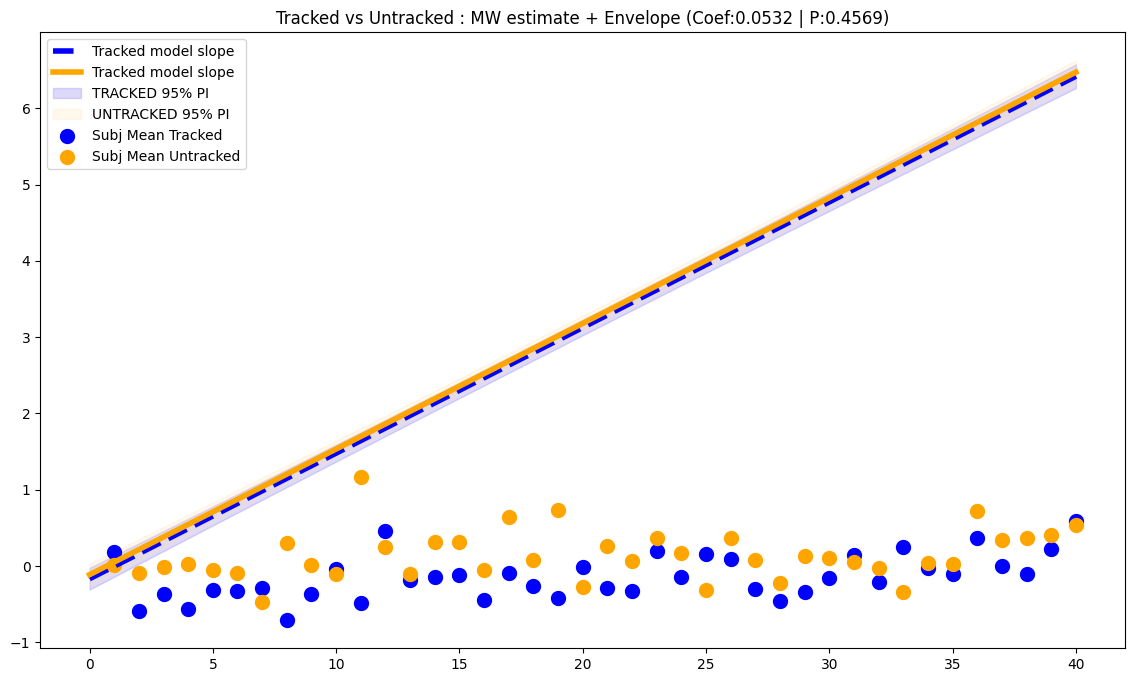

In [39]:

fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',grand_df,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    1125      Method:               REML       
No. Groups:          29        Scale:                0.9558     
Min. group size:     17        Log-Likelihood:       -1578.9907 
Max. group size:     40        Converged:            No         
Mean group size:     38.8                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.321    0.065 -4.894 0.000 -0.449 -0.192
Tracking[T.UNTRACKED]  0.274    0.058  4.697 0.000  0.160  0.388
trialNum               0.009    0.003  3.616 0.000  0.004  0.014
DS Var                 0.000                                    



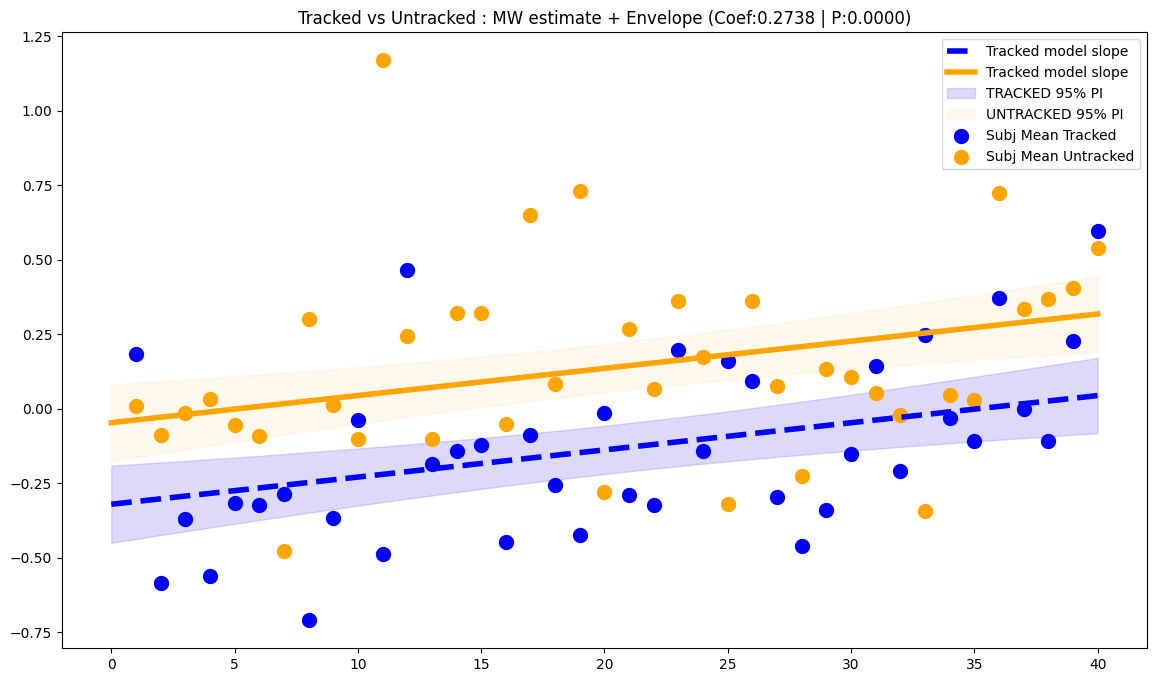

In [40]:

### Get the parameters of a linear model: 
import matplotlib.pyplot as plt


### Model Checks: 
import statsmodels.api  as sm

import statsmodels.formula.api as smf

m = smf.mixedlm("MW_Estimate ~ Tracking+trialNum ", data=grand_df[['DS','trialNum','Tracking','MW_Estimate']],
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("MW Estimate")
eye.append('')
analysis.append('')

log_file.write("\n===# (1) Uncorrected Samples #=== \n\n")
log_file.write("(1.1) Uncorrected Samples (MW ~ Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")


fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',grand_df,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )
plt.savefig(os.path.join(statPath,f"MWvsUntracked_Unc_{est}_{exclusionName}.svg"))



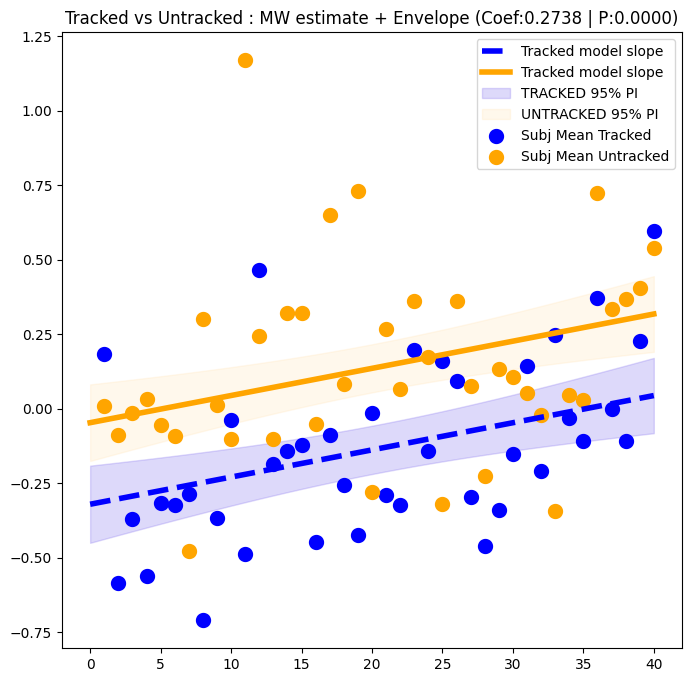

In [41]:

fig, ax = plt.subplots(figsize=(8, 8))
plotTrialTrack(m,'MW_Estimate',grand_df,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )
plt.savefig(os.path.join(statPath,f"MWvsUntracked_Unc_{est}_{exclusionName}.svg"))


#### Checks

**Chek the assumptions of linear models**
+ Homoscedasticity
+ Normality of residuals
+ vfs

Intercept                5.046597
Tracking[T.UNTRACKED]    1.000089
trialNum                 1.000089
dtype: float64


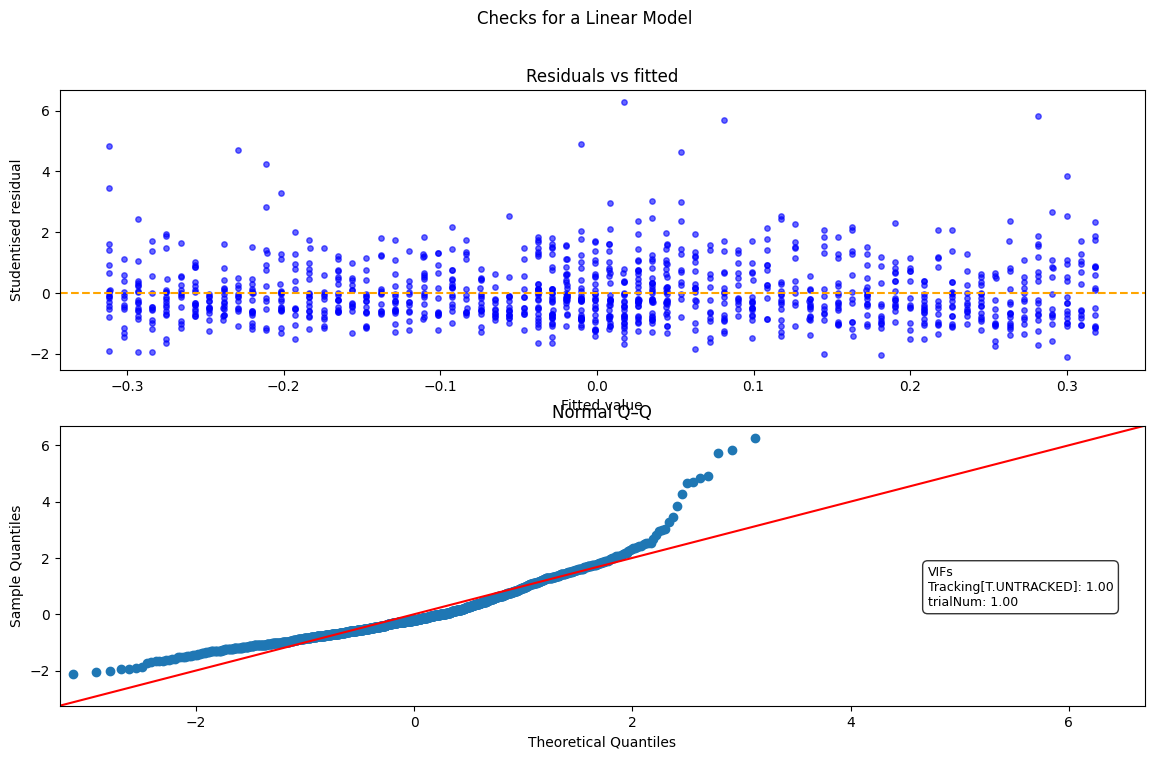

In [ ]:
from analysisFunctions import linearModelChecks
### Checks the assumptioons of a linear model 
linearModelChecks(m,grand_df,formula="MW_Estimate ~ Tracking+trialNum ")
plt.savefig(os.path.join(statPath,f"MWvsUntracked_Unc_Checks_{est}_{exclusionName}.png"))

**Check the Mean of  MW estimated for every Particiapnt**

The purpose is to plot whether by means alone we cane see the relationship

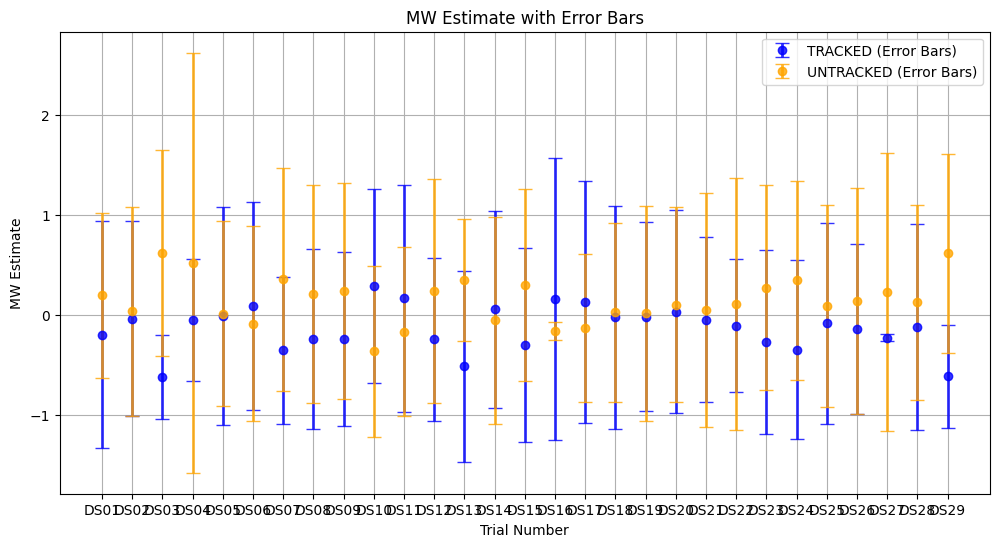

In [43]:
mew = grand_df[grand_df['Tracking'] == 'TRACKED'][['DS','MW_Estimate']].groupby(['DS'])
umew = grand_df[grand_df['Tracking'] == 'UNTRACKED'][['DS','MW_Estimate']].groupby(['DS'])


plt.figure(figsize=(12, 6))

# Plot for TRACKED group
plt.errorbar(mew.mean().index, 
             mew.mean()['MW_Estimate'].values, 
             yerr=mew.std()['MW_Estimate'].values, 
             fmt='o', color='blue', label='TRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Plot for UNTRACKED group
plt.errorbar(umew.mean().index, 
             umew.mean()['MW_Estimate'].values, 
             yerr=umew.std()['MW_Estimate'].values, 
             fmt='o', color='orange', label='UNTRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Add labels, legend, and title
plt.xlabel('Trial Number')
plt.ylabel('MW Estimate')
plt.title('MW Estimate with Error Bars')
plt.legend()
plt.grid(True)

# Show the plot
plt.savefig(os.path.join(statPath,f"MWacrossSubj_Unc_{est}_{exclusionName}.png"))

### (1.2) Test Whether Attentiveness (Mind Wandering vs Focus) is related to Mind Wandering Estimate 

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   MW_Estimate
No. Observations:   1125      Method:               REML       
No. Groups:         29        Scale:                0.9683     
Min. group size:    17        Log-Likelihood:       -1586.1071 
Max. group size:    40        Converged:            Yes        
Mean group size:    38.8                                       
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            -0.223    0.061 -3.669 0.000 -0.343 -0.104
C(Attention2)[T.3.0]  0.192    0.071  2.705 0.007  0.053  0.331
trialNum              0.009    0.003  3.556 0.000  0.004  0.014
DS Var                0.000                                    



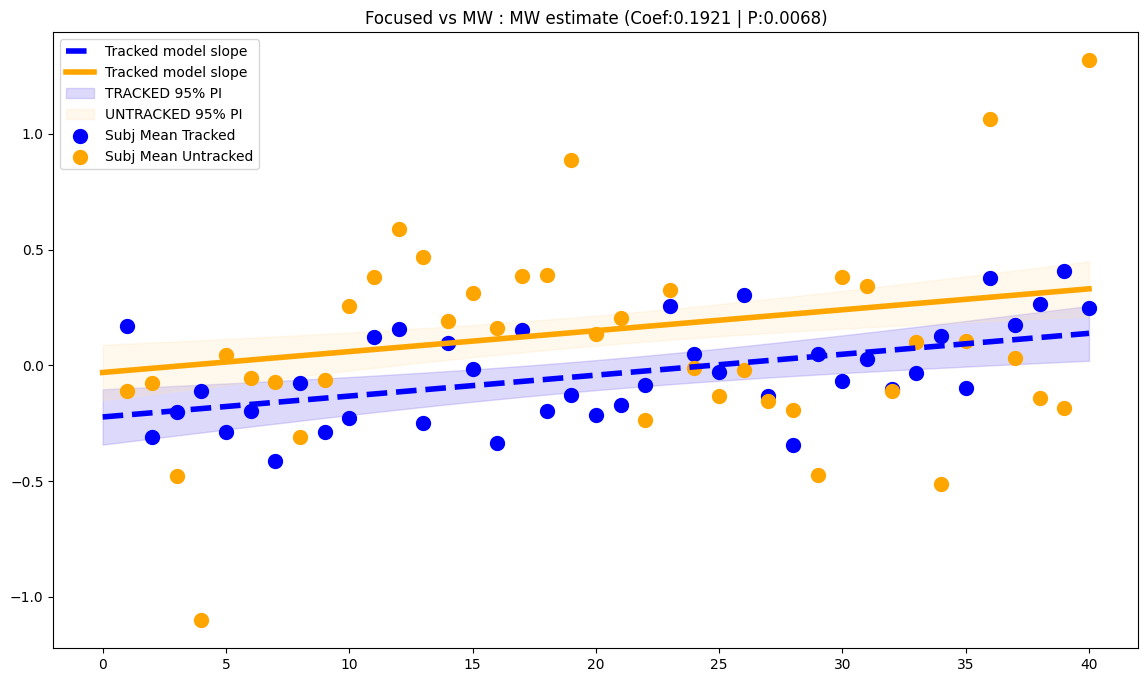

In [44]:

current_df = grand_df

current_df

m = smf.mixedlm("MW_Estimate ~ C(Attention2)+trialNum ", data=current_df,
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("MW Estimate")
eye.append('')
analysis.append('')

log_file.write("\n===# (1) Uncorrected Samples #=== \n\n")
log_file.write("(1.1) Uncorrected Samples (MW ~ Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")


fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',grand_df,ax,titl=f"Focused vs MW : MW estimate (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",paramNum=[0,1,2],anlysisName = 'Attention2',firstContrast=1,lastContrast =3 )
plt.savefig(os.path.join(statPath,f"MWvsUntracked_Unc_{est}_{exclusionName}.svg"))


In [45]:
statPath

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\SecondExp\\NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean\\summary\\mode_zscore___mmTrue'

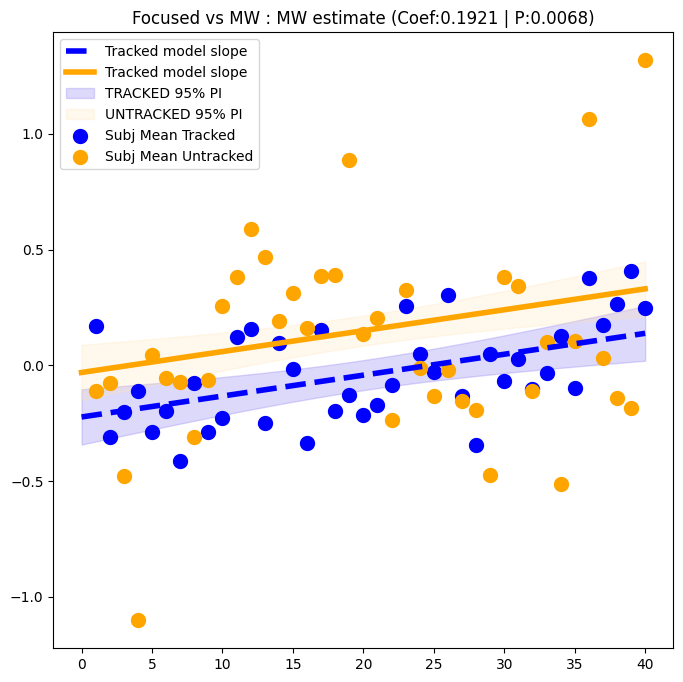

In [46]:


def plotTrialTrack(m,name,grand_df,ax,titl,paramNum=[0,1,2],anlysisName = 'Tracking',firstContrast='TRACKED',lastContrast = 'UNTRACKED'):
    ### QUick Linear Model 
    quick_untracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[1]]]+m.params[m.params.keys()[paramNum[2]]]*x 
    quick_tracked_lm = lambda x: m.params[m.params.keys()[paramNum[0]]] + m.params[m.params.keys()[paramNum[2]]]*x

    trialN = np.linspace(0,len(np.unique(grand_df['trialNum'])),len(np.unique(grand_df['trialNum']))+1);
    mw_est_utr = pd.Series(trialN).apply(quick_untracked_lm)
    mw_est_tr = pd.Series(trialN).apply(quick_tracked_lm)

    ax.set_title(titl)
    ax.plot(trialN,mw_est_tr,label="Tracked model slope",color="blue",linewidth=4,linestyle='--')
    ax.plot(trialN,mw_est_utr,label="Tracked model slope",color="orange",linewidth=4)
    grTr = grand_df[[name,'trialNum',anlysisName]].groupby([anlysisName,'trialNum'])
    from scipy.stats import t

    # --- pieces from the fitted model ---
    Vbeta  = m.cov_params().loc[m.params.index, m.params.index]  # Cov(beta)
    tval   = t.ppf(0.975, df=m.df_resid)                         # 95% PI; change if needed

    # --- build X matrices consistent with your lambdas: [1, Tracking, trialNum] ---
    pnames = list(m.params.index)                # keeps exact column order used by model
    col = {name:i for i, name in enumerate(pnames)}

    def build_X(tracking): # Build simple model matrix (for tracked and untracked separately)
        X = np.zeros((len(trialN), len(pnames)))
        # these names match the terms in your formula
        X[:, col.get('Intercept', 0)] = 1.0
        if anlysisName == "Tracking":
            ttr =  'Tracking[T.UNTRACKED]'
        else:
            ttr =  'C(Attention)[T.3]'

        if ttr in col: X[:, col[ttr]] = tracking
        if 'trialNum' in col: X[:, col['trialNum']] = trialN
        return X

    X_tr  = build_X(1.0)   # tracked
    X_un  = build_X(0.0)   # untracked
    # --- se of mean and se of prediction at each trial ---
    se_mean_tr = np.sqrt(np.einsum('ij,jk,ik->i', X_tr, Vbeta.values, X_tr))
    se_mean_un = np.sqrt(np.einsum('ij,jk,ik->i', X_un, Vbeta.values, X_un))


    # --- add ribbons using your lambdas' fitted lines ---
    ax.fill_between(trialN, mw_est_tr  - tval*se_mean_tr, mw_est_tr  + tval*se_mean_tr,
                    color='mediumslateblue', alpha=0.25, label='TRACKED 95% PI')
    ax.fill_between(trialN, mw_est_utr - tval*se_mean_un, mw_est_utr + tval*se_mean_un,
                color='moccasin', alpha=0.25, label='UNTRACKED 95% PI')


    ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue',linewidth=5)
    ax.scatter(grTr.mean().loc[lastContrast].index,grTr.mean().loc[lastContrast],label="Subj Mean Untracked",color = 'orange',linewidth=5)
    ax.set_xlabel="Trial Number"
    ax.legend()
  
fig, ax = plt.subplots(figsize=(8, 8))
plotTrialTrack(m,'MW_Estimate',grand_df,ax,titl=f"Focused vs MW : MW estimate (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})",paramNum=[0,1,2],anlysisName = 'Attention2',firstContrast=1,lastContrast =3 )
plt.savefig(os.path.join(statPath,f"MWvsAttention_Unc_{est}_{exclusionName}.svg"))


In [55]:
grand_df.to_csv(os.path.join(statPath,f"all_data_behav_only2.csv"),index=False)

In [56]:
statPath

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\SecondExp\\NEW_TEST_withoutCenter_resVAR100_dgv5_bll500_blb75_smw10_smL2000_swG50_trOall_trB5000mean\\summary\\mode_zscore___mmTrue'

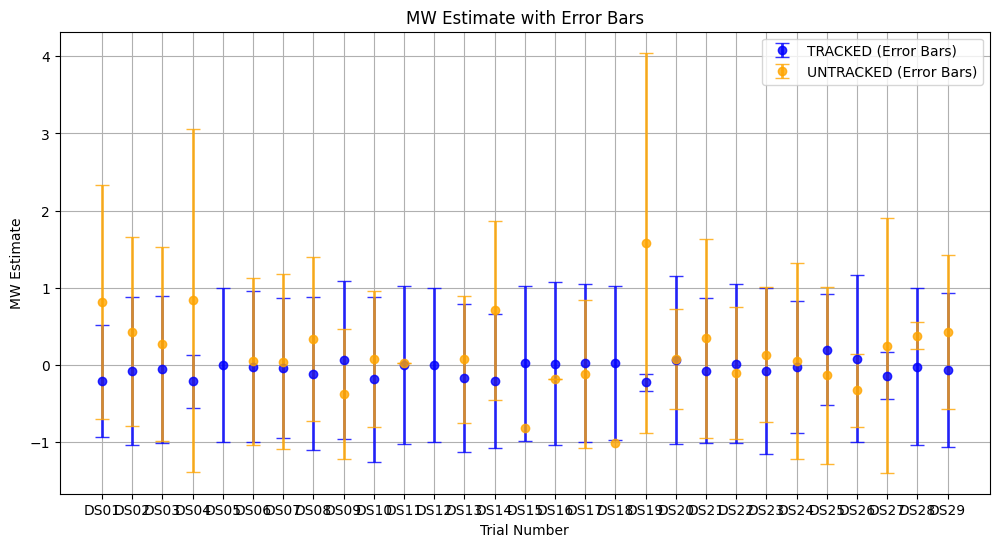

In [47]:
mew = grand_df[grand_df['Attention2'] == 1][['DS','MW_Estimate']].groupby(['DS'])
umew = grand_df[grand_df['Attention2'] == 3][['DS','MW_Estimate']].groupby(['DS'])


plt.figure(figsize=(12, 6))

# Plot for TRACKED group
plt.errorbar(mew.mean().index, 
             mew.mean()['MW_Estimate'].values, 
             yerr=mew.std()['MW_Estimate'].values, 
             fmt='o', color='blue', label='TRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Plot for UNTRACKED group
plt.errorbar(umew.mean().index, 
             umew.mean()['MW_Estimate'].values, 
             yerr=umew.std()['MW_Estimate'].values, 
             fmt='o', color='orange', label='UNTRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Add labels, legend, and title
plt.xlabel('Trial Number')
plt.ylabel('MW Estimate')
plt.title('MW Estimate with Error Bars')
plt.legend()
plt.grid(True)

# Show the plot
plt.savefig(os.path.join(statPath,f"MWacrossSubj_Unc_{est}_{exclusionName}.png"))

In [48]:
grand_df['MW_Estimate']

0       1.151388
1      -0.769815
2      -0.716449
3      -0.823182
4       0.617720
          ...   
1155    0.953240
1156   -0.939719
1157    0.682817
1158   -0.849578
1159   -0.759437
Name: MW_Estimate, Length: 1125, dtype: float64

Intercept     6.939894
Attention2    1.000871
trialNum      1.000871
dtype: float64


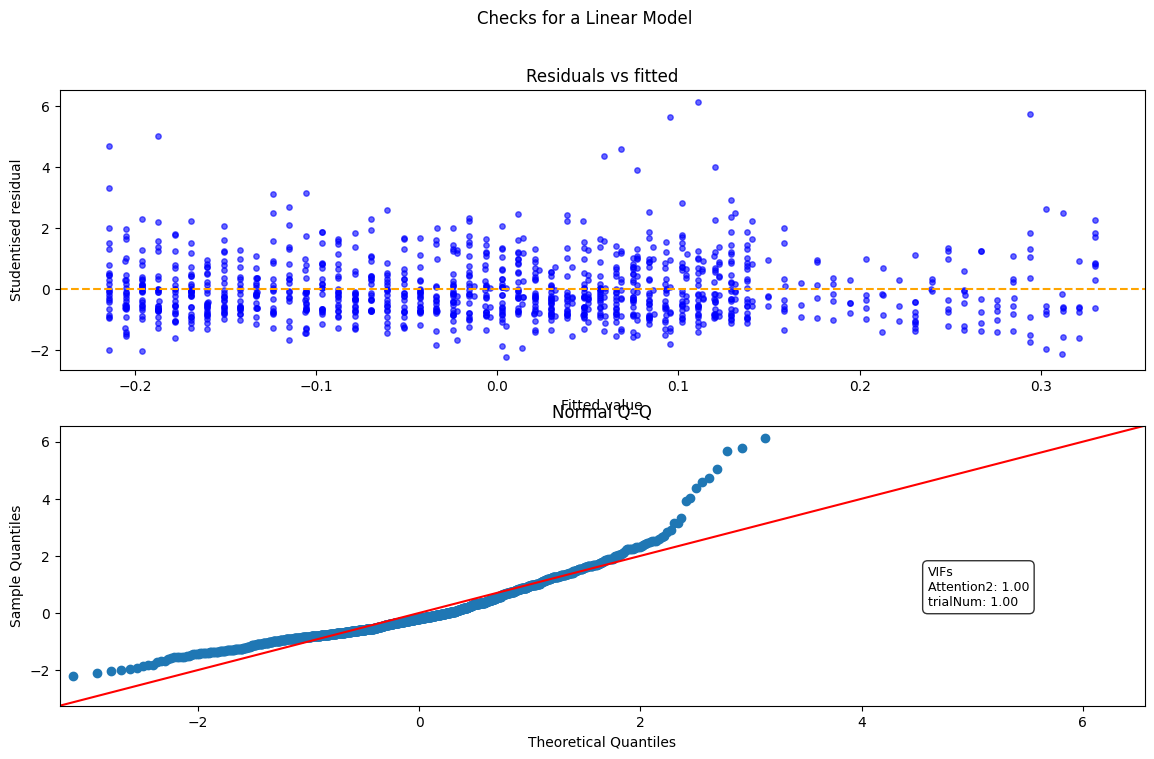

In [49]:

def linearModelChecks(m,grand_df,formula =  "MW_Estimate ~ Tracking + trialNum"):
    # trial-level diagnostics
    resid   = m.resid                   # raw (conditional) residuals
    fitted  = m.fittedvalues            # conditional fitted values
    std_res = resid / np.sqrt(m.scale)  # ≈ studentised residuals
    fig,axs = plt.subplots(2,1,figsize=(14, 8))
    plt.suptitle("Checks for a Linear Model")

    # (1) Homoscedascisity
    axs[0].scatter(fitted, std_res, alpha=0.6, s=15,color='blue')
    axs[0].axhline(0, linestyle='--',color='orange')
    axs[0].set_xlabel("Fitted value")
    axs[0].set_ylabel("Studentised residual")
    axs[0].set_title("Residuals vs fitted")

    # (2) 
    sm.qqplot(std_res, line="45", fit=True, ax=axs[1])
    axs[1].set_title("Normal Q–Q")

    # (3) Colinearity:
    from patsy import dmatrices

    formula_fixed = formula  # your fixed part
    y, X = dmatrices(formula_fixed, data=grand_df, return_type="dataframe")
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    )
    print(vif)

     # Drop the intercept from display (its VIF is usually not meaningful)
    vif_display = vif.drop('Intercept', errors='ignore')
    
    # Convert to multiline string
    vif_text = "\n".join([f"{k}: {v:.2f}" for k, v in vif_display.items()])
    vif_text = f"VIFs\n{vif_text}"

    axs[1].text(
        0.8, 0.5, vif_text,
        transform=axs[1].transAxes,
        verticalalignment='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
    )
linearModelChecks(m,grand_df,formula="MW_Estimate ~ Attention2+trialNum ")


### (1.3) Test Whether Attentiveness (4 stages) is related to Mind Wandering Estimate 

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\base

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  MW_Estimate
No. Observations:    1125     Method:              REML       
No. Groups:          29       Scale:               0.9671     
Min. group size:     17       Log-Likelihood:      -1586.5396 
Max. group size:     40       Converged:           No         
Mean group size:     38.8                                     
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           -0.228    0.067 -3.419 0.001 -0.359 -0.097
C(Attention)[T.2.0]  0.023    0.066  0.345 0.730 -0.107  0.153
C(Attention)[T.3.0]  0.176    0.080  2.214 0.027  0.020  0.333
C(Attention)[T.4.0]  0.687    0.277  2.476 0.013  0.143  1.230
trialNum             0.009    0.003  3.407 0.001  0.004  0.014
DS Var               0.000                                    



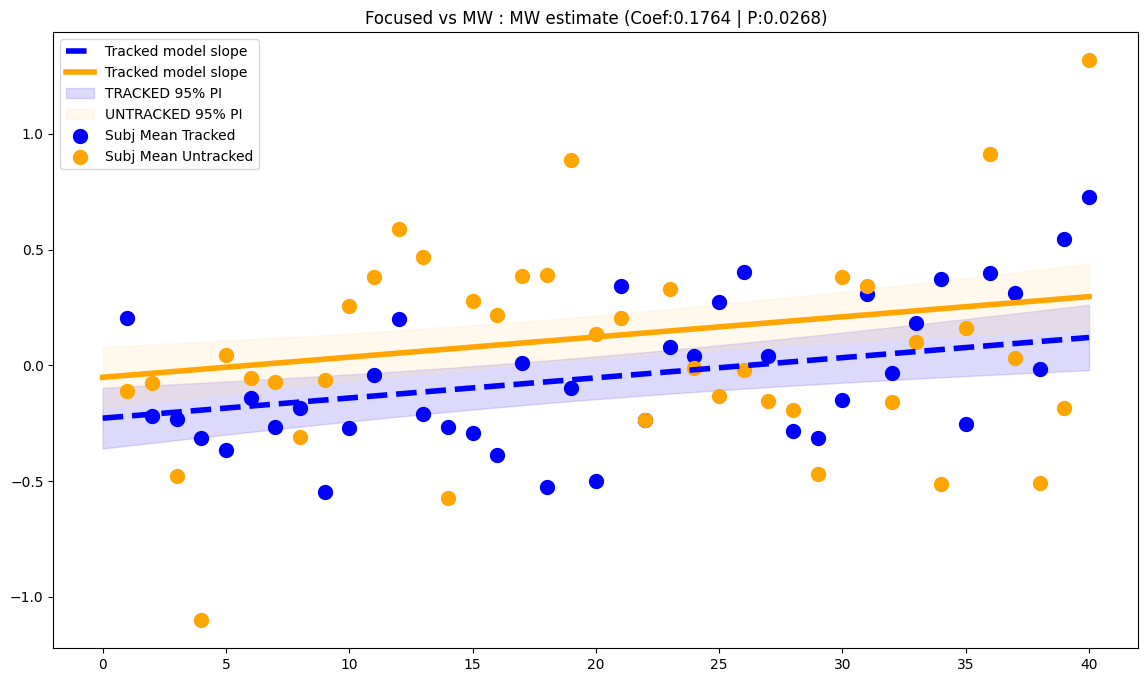

In [50]:
m = smf.mixedlm("MW_Estimate ~ C(Attention)+trialNum ", data=grand_df,
                groups="DS",          # random intercept
                #re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   
coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("MW Estimate")
eye.append('')
analysis.append('')

log_file.write("\n===# (1) Uncorrected Samples #=== \n\n")
log_file.write("(1.1) Uncorrected Samples (MW ~ Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")


fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',grand_df,ax,titl=f"Focused vs MW : MW estimate (Coef:{ m.params[m.params.keys()[2]]:1.4f} | P:{ m.pvalues[m.params.keys()[2]]:1.4f})",paramNum=[0,2,4],anlysisName = 'Attention',firstContrast=1,lastContrast =3 )
plt.savefig(os.path.join(statPath,f"MWvsUntracked_Unc_{est}_{exclusionName}.png"))


Intercept    8.894070
Attention    1.008924
trialNum     1.008924
dtype: float64


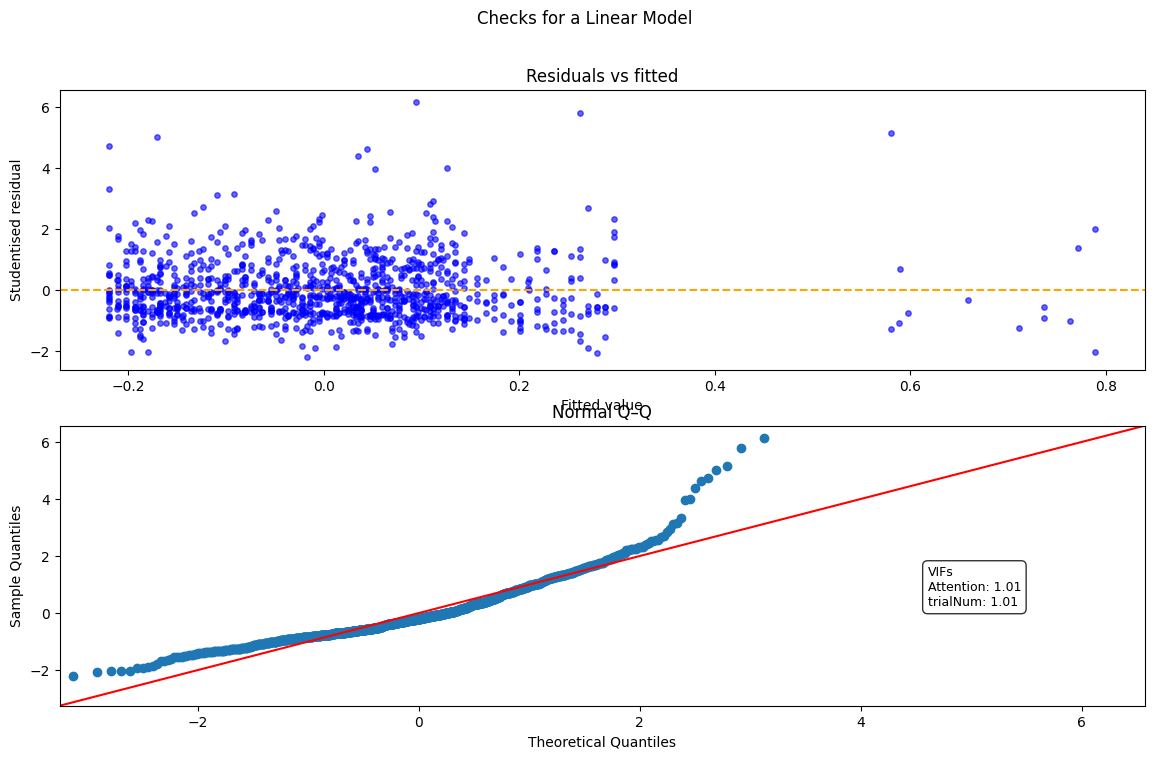

In [51]:

def linearModelChecks(m,grand_df,formula =  "MW_Estimate ~ Tracking + trialNum"):
    # trial-level diagnostics
    resid   = m.resid                   # raw (conditional) residuals
    fitted  = m.fittedvalues            # conditional fitted values
    std_res = resid / np.sqrt(m.scale)  # ≈ studentised residuals
    fig,axs = plt.subplots(2,1,figsize=(14, 8))
    plt.suptitle("Checks for a Linear Model")

    # (1) Homoscedascisity
    axs[0].scatter(fitted, std_res, alpha=0.6, s=15,color='blue')
    axs[0].axhline(0, linestyle='--',color='orange')
    axs[0].set_xlabel("Fitted value")
    axs[0].set_ylabel("Studentised residual")
    axs[0].set_title("Residuals vs fitted")

    # (2) 
    sm.qqplot(std_res, line="45", fit=True, ax=axs[1])
    axs[1].set_title("Normal Q–Q")

    # (3) Colinearity:
    from patsy import dmatrices

    formula_fixed = formula  # your fixed part
    y, X = dmatrices(formula_fixed, data=grand_df, return_type="dataframe")
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    vif = pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns
    )
    print(vif)

     # Drop the intercept from display (its VIF is usually not meaningful)
    vif_display = vif.drop('Intercept', errors='ignore')
    
    # Convert to multiline string
    vif_text = "\n".join([f"{k}: {v:.2f}" for k, v in vif_display.items()])
    vif_text = f"VIFs\n{vif_text}"

    axs[1].text(
        0.8, 0.5, vif_text,
        transform=axs[1].transAxes,
        verticalalignment='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8)
    )
linearModelChecks(m,grand_df,formula="MW_Estimate ~ Attention+trialNum ")


### (1.4) Test Whether Cued vs Uncued is different in Subject Estimated Attentiveness (Mind Wandering vs Focus )

### (1.5) Test Whether Cued vs Uncued is different in Subject Estimated Attentiveness (Mind Wandering vs Focus )

## (2) CORRECTED: Test Is Tracked Entity Different from Untracked Entity?

Since there are some trials and subjects that are clearly Unreliable, we can exclude them based on preordained criteria:

(WARNING it may be relevant only for Pupil Diameter dependent measures )

- Those that No-Pupi Events (Blinks, Outside of the screen) have not been more than 10%
- Those that General No screen + Clustering have not been 75%
- Those in which Pupil Period is not contaminated by Measurments and the rate of artefacts is less than 0.05

#### (1.1) Test Whether Pupil Diameter Differs between Tracked and Untracked Entity: 

We controll immediatley for SUBJECTS

so Making Basic Models:

        MW_estimate ~ Tracking +trialNum + (1|Subjects)


Additionally we plot the Envelope of STD from subjects as well as provide the Mean differs across subjects of MW Both in TIme as in Absolute:

Important here to check:
+ Whether there is a difference between Tracked and Untracked Entity
+ Whether there is an Effect of Trial Number (As MW Rate should increase in time)

In [52]:
grand_df

,MW_Estimate,Tracking,DS,trialNum,goodRatioLeft,goodPupRatioLeft,saccadeRate,blinkRate,gazeRate,Subject,Fragment,Attention,lemmaN,utt_leng,FragmentSentCosSim,Attention2
0,1.151388,UNTRACKED,DS01,1,0.985204,0.999734,2.302091,1.174536,0.082989,ADNA2507,recall_KAROLINA_1,3.0,10.0,118.0,0.271289,3.0
1,-0.769815,TRACKED,DS01,2,0.984472,1.000000,2.257196,1.076828,0.071473,ADNA2507,recall_JANEK_1,1.0,12.0,121.0,0.323691,1.0
2,-0.716449,UNTRACKED,DS01,3,0.984744,1.000000,2.461236,1.329067,0.095719,ADNA2507,recall_KAROLINA_2,1.0,16.0,216.0,0.185791,1.0
3,-0.823182,TRACKED,DS01,4,0.969668,1.000000,2.187206,1.222954,0.084509,ADNA2507,recall_JANEK_2,1.0,10.0,116.0,0.375014,1.0
4,0.617720,UNTRACKED,DS01,5,0.978186,1.000000,2.847956,1.607717,0.116102,ADNA2507,recall_KAROLINA_3,2.0,15.0,154.0,0.376438,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1155,0.953240,UNTRACKED,DS29,36,0.845116,0.930902,1.499893,0.857082,0.166831,TYTO1309,recall_JANEK_18,2.0,10.0,166.0,0.289113,1.0
1156,-0.939719,TRACKED,DS29,37,0.957317,0.981389,1.854111,0.829471,0.097029,TYTO1309,recall_KAROLINA_19,2.0,20.0,248.0,0.283937,1.0
1157,0.682817,UNTRACKED,DS29,38,0.940990,0.965078,1.786522,1.130710,0.145815,TYTO1309,recall_JANEK_19,2.0,17.0,207.0,0.197682,1.0
1158,-0.849578,TRACKED,DS29,39,0.847412,0.954328,1.434334,0.761990,0.139387,TYTO1309,recall_KAROLINA_20,2.0,13.0,164.0,0.253871,1.0


In [53]:

from analysisFunctions import qualityChecks
partiaclCheck0 = grand_df[grand_df['gazeRate'] <0.20]
partiaclCheck1L,partiaclCheck2L,trmw1L,untrmw1L,trmw2L,untrmw2L =  qualityChecks(partiaclCheck0,'Left')
partiaclCheck1R,partiaclCheck2R,trmw1R,untrmw1R,trmw2R,untrmw2R =  qualityChecks(partiaclCheck0,'Right')

mw = grand_df[grand_df['Tracking'] == 'TRACKED'].groupby(['Tracking','DS'])
umw = grand_df[grand_df['Tracking'] == 'UNTRACKED'].groupby(['Tracking','DS'])

trmw = partiaclCheck0[partiaclCheck0['Tracking']=="TRACKED"].groupby(['Tracking','DS'])
untrmw  = partiaclCheck0[partiaclCheck0['Tracking']=="UNTRACKED"].groupby(['Tracking','DS'])


log_file.write("\n===# CHECKS #=== \n\n")
log_file.write(f"   Gaze Rate Rej Threshold:      {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Left NaN Rej Threshold:       {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Right NaN Rej Threshold:      {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Left Pup NaN Rej Threshold:   {0.1*100}%\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")
log_file.write(f"   Right Pup NaN Rej Threshold:  {0.1*100}%\n\n")
log_file.write(f"      N. After Removal:           (Tr: {int(trmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")

print(f"   Gaze Rate Rej Threshold:      {0.1*100}%")
print(f"      N. After Removal:           (Tr: {int(trmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"   NaN Rej Threshold:            {0.751*100}%")
print(f"      N. After Removal:           (Tr: {int(trmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"      N. After Removal:           (Tr: {int(trmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw1R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"   Pup NaN Rej Threshold:        {0.95*100}%")
print(f"      N. After Removal:           (Tr: {int(trmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2L.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )")
print(f"      N. After Removal:           (Tr: {int(trmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(mw.count().sum().loc['MW_Estimate'].iloc[0])} || Untr: {int(untrmw2R.count().sum().loc['MW_Estimate'].iloc[0])}/{int(umw.count().sum().loc['MW_Estimate'].iloc[0])} )\n")


for i,ds in enumerate(grand_df['DS'].unique()):
    print(i)
    log_file.write(f"\n  ={ds}= \n\n")
    log_file.write(f"      N. good Trials            {len(np.unique(partiaclCheck0[partiaclCheck0['DS'] == ds]['trialNum']))}\n")
    log_file.write(f"      N. of NaN Trials:         {np.sum(grand_df[grand_df['DS'] ==ds]['Pupil_Diameter']['Mean']['Left_Eye'].isna())}/{len(grand_df[grand_df['DS'] == ds])}\n")
    log_file.write(f"      Mean non Gaze Rate:       {grand_df[grand_df['DS'] == ds]['Checks']['']['gazeRate'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['gazeRate'].std():3.3f})\n")
    log_file.write(f"      Mean R/L Pupil Diff:      {grand_df[grand_df['DS'] == ds]['Checks']['']['pupilDiff'].mean():3.3f} ({grand_df[grand_df['DS'] == ds]['Checks']['']['pupilDiff'].std():3.3f})\n")





KeyError: 'Checks'

In [ ]:
partiaclCheck0

MW_Estimate GazeDifference Pupil_Diameter                                \
                                          Mean                 Std             
                                      Left_Eye Right_Eye  Left_Eye Right_Eye   
0       0.788517      18.101889      -0.103120 -0.109114  0.047323  0.062290   
1       1.961518      22.222548      -0.158326 -0.155978  0.075676  0.101594   
2      -0.123817      27.139951      -0.502426 -0.494871  0.050259  0.058449   
3       1.179518      29.549453       0.115806  0.080705  0.054622  0.068420   
4      -1.166484      23.759388       0.236644  0.261647  0.043348  0.052436   
...          ...            ...            ...       ...       ...       ...   
1235    2.396204      58.504876       0.182832  0.154193  0.011103  0.012642   
1236    0.101248      47.530693       0.295220  0.235178  0.023395  0.020739   
1237    1.518721      34.711861      -0.325025 -0.239333  0.016567  0.014852   
1238    0.776235      64.811923       0.491732  0.469421  0.004788  0.004570   
1239    0.506240      45.357810       0.150677  0.102697  0.009355  0.005881   

                                                  ...          Blinks  \
          diff                   auc              ...                   
      Left_Eye Right_Eye    Left_Eye   Right_Eye  ... BlinkDurationSd   
0    -0.014033 -0.033033 -127.457307 -121.984577  ...        0.000000   
1    -0.002367  0.064700 -196.102017 -174.828924  ...        4.109609   
2    -0.617938 -0.537224 -621.752195 -553.934958  ...       37.553162   
3     0.163267  0.126867  143.295039   90.335311  ...        7.000000   
4     0.868477  0.920932  292.851907  292.825225  ...        2.000000   
...        ...       ...         ...         ...  ...             ...   
1235  0.277055  0.226560  226.316560  172.695939  ...       25.000000   
1236 -0.252900 -0.219733  365.511032  263.403824  ...        0.000000   
1237 -0.110633 -0.108300 -402.090435 -267.828856  ...       25.350871   
1238  0.510733  0.347800  608.515815  525.473143  ...        0.000000   
1239  0.350633  0.281500  186.522909  115.028127  ...        0.000000   

           Gaze                                                         \
           mean                                         std              
          LeftX     RightX      LeftY     RightY      LeftX     RightX   
0     -5.180038   1.430879  13.640607  12.334918  21.956711  37.227858   
1      4.979870   3.231624  24.761804  16.123034  24.331118  31.999294   
2      2.827393   7.822771  26.770444  14.884055  26.600568  35.130628   
3      2.337945  13.273565  24.235699  11.049062  17.384414  39.034364   
4     11.875938   8.239643  32.495445  16.842053  23.441960  31.770694   
...         ...        ...        ...        ...        ...        ...   
1235  49.759927   5.789413   8.192781 -12.928598  86.163109  82.211977   
1236  59.669087  19.761543  17.059959  -3.551375  24.702066  33.964808   
1237  58.059869  19.867823   2.632861  -0.222344  61.589897  67.468466   
1238  55.260116   6.920000  18.380610  11.848947  14.567815  39.044223   
1239  61.005148  17.343731  15.864174   0.076092  26.828689  26.785697   

                             Subject  
                                      
          LeftY     RightY            
0     84.893609  65.579048  AGKO2706  
1     82.936829  61.908959  AGKO2706  
2     82.124156  55.709345  AGKO2706  
3     76.592304  64.854248  AGKO2706  
4     77.031041  52.057982  AGKO2706  
...         ...        ...       ...  
1235  85.399931  77.543223  ZURY1007  
1236  38.058904  30.402958  ZURY1007  
1237  83.464941  80.051645  ZURY1007  
1238  29.971249  34.259437  ZURY1007  
1239  24.010375  23.205997  ZURY1007  

[1129 rows x 46 columns]

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   MW_Estimate
No. Observations:    1129      Method:               REML       
No. Groups:          29        Scale:                0.8957     
Min. group size:     26        Log-Likelihood:       -1548.0304 
Max. group size:     40        Converged:            Yes        
Mean group size:     38.9                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.488    0.064 -7.666 0.000 -0.612 -0.363
Tracking[T.UNTRACKED]  0.323    0.056  5.731 0.000  0.212  0.433
trialNum               0.015    0.002  6.123 0.000  0.010  0.020
DS Var                 0.000                                    



c:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\analysisFunctions.py:1964: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ax.scatter(grTr.mean().loc[firstContrast].index,grTr.mean().loc[firstContrast],label="Subj Mean Tracked",color = 'blue')


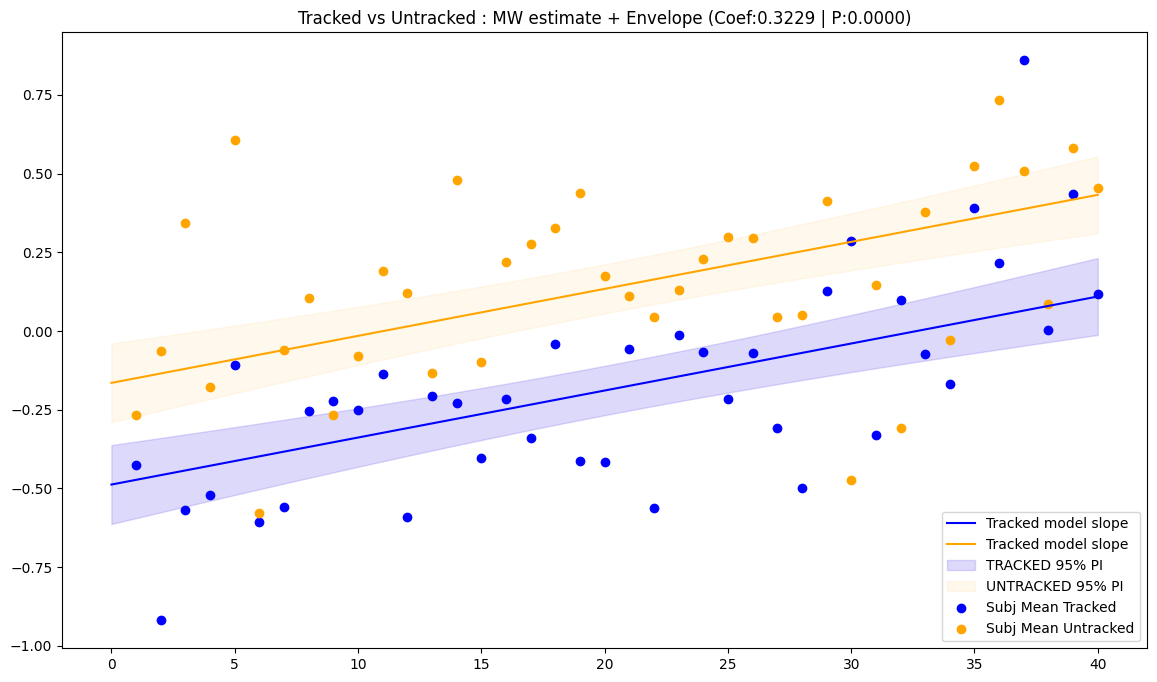

In [ ]:
### Current Subject Specfic Checks: 
# 1)


import statsmodels.formula.api as smf

m = smf.mixedlm("MW_Estimate ~ Tracking+ trialNum ", data=partiaclCheck0[['DS','trialNum','Tracking','MW_Estimate']],
                groups="DS",          # random intercept
               # re_formula="~Tracking",         # adds random slope

               ).fit()
print(m.summary())   


log_file.write("\n===# (1) Uncorrected Samples #=== \n\n")
log_file.write("(1.1) Uncorrected Samples (MW ~ Tracking +TrialNum +(1|Subjects)) \n")

log_file.write(f"      Tracking Effect        (Coef: {m.params[m.params.keys()[1]]:3.3f}| Z: {m.tvalues[m.params.keys()[1]]:3.3f}| P: {m.pvalues[m.params.keys()[1]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[1]][0]:3.3f} {m.conf_int().loc[m.params.keys()[1]][1]:3.3f})\n")
log_file.write(f"      Trial Number Effect    (Coef: {m.params[m.params.keys()[2]]:3.3f}| Z: {m.tvalues[m.params.keys()[2]]:3.3f}| P: {m.pvalues[m.params.keys()[2]]:3.3f} | Conf: {m.conf_int().loc[m.params.keys()[2]][0]:3.3f} {m.conf_int().loc[m.params.keys()[2]][1]:3.3f})\n")

coefs.append(m.params[m.params.keys()[1]])
zvals.append(m.tvalues[m.params.keys()[1]])
pvals.append(m.pvalues[m.params.keys()[1]])
conf1.append(m.conf_int().loc[m.params.keys()[1]][0])
conf2.append(m.conf_int().loc[m.params.keys()[1]][1])

coefsT.append(m.params[m.params.keys()[2]])
zvalsT.append(m.tvalues[m.params.keys()[2]])
pvalsT.append(m.pvalues[m.params.keys()[2]])
conf1T.append(m.conf_int().loc[m.params.keys()[2]][0])
conf2T.append(m.conf_int().loc[m.params.keys()[2]][1])

indx.append("MW Estimate Corr")
eye.append('')
analysis.append('Tracking')

fig, ax = plt.subplots(figsize=(14, 8))
plotTrialTrack(m,'MW_Estimate',partiaclCheck0,ax,titl=f"Tracked vs Untracked : MW estimate + Envelope (Coef:{ m.params[m.params.keys()[1]]:1.4f} | P:{ m.pvalues[m.params.keys()[1]]:1.4f})" )
plt.savefig(os.path.join(statPath,f"MWvsUntracked_corr_{est}_{exclusionName}.png"))

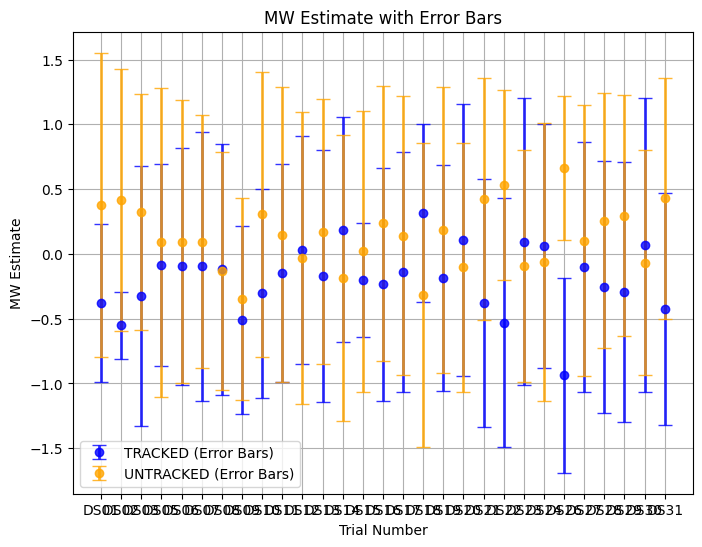

In [ ]:
mew2 = partiaclCheck0[partiaclCheck0['Tracking'] == 'TRACKED'][['DS','MW_Estimate']].groupby(['DS'])
ume2 = partiaclCheck0[partiaclCheck0['Tracking'] == 'UNTRACKED'][['DS','MW_Estimate']].groupby(['DS'])


plt.figure(figsize=(8, 6))

# Plot for TRACKED group
plt.errorbar(mew2.mean().index, 
             mew2.mean()['MW_Estimate'].values, 
             yerr=mew2.std()['MW_Estimate'].values, 
             fmt='o', color='blue', label='TRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Plot for UNTRACKED group
plt.errorbar(ume2.mean().index, 
             ume2.mean()['MW_Estimate'].values, 
             yerr=ume2.std()['MW_Estimate'].values, 
             fmt='o', color='orange', label='UNTRACKED (Error Bars)', alpha=0.8, 
             capsize=5, elinewidth=2)  # Adjust capsize and line width

# Add labels, legend, and title
plt.xlabel('Trial Number')
plt.ylabel('MW Estimate')
plt.title('MW Estimate with Error Bars')
plt.legend()
plt.grid(True)

# Show the plot
plt.savefig(os.path.join(statPath,f"MWacrossSubj_Corr_{est}_{exclusionName}.png"))